In [1]:
import pandas as pd

UNEMPLOYMENT ANALYSIS - OIBSIP TASK 2

First 5 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Dataset Shape:
(768, 7)

Co

C:\Users\SAUS\AppData\Local\Temp\ipykernel_3152\1536145642.py:40: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


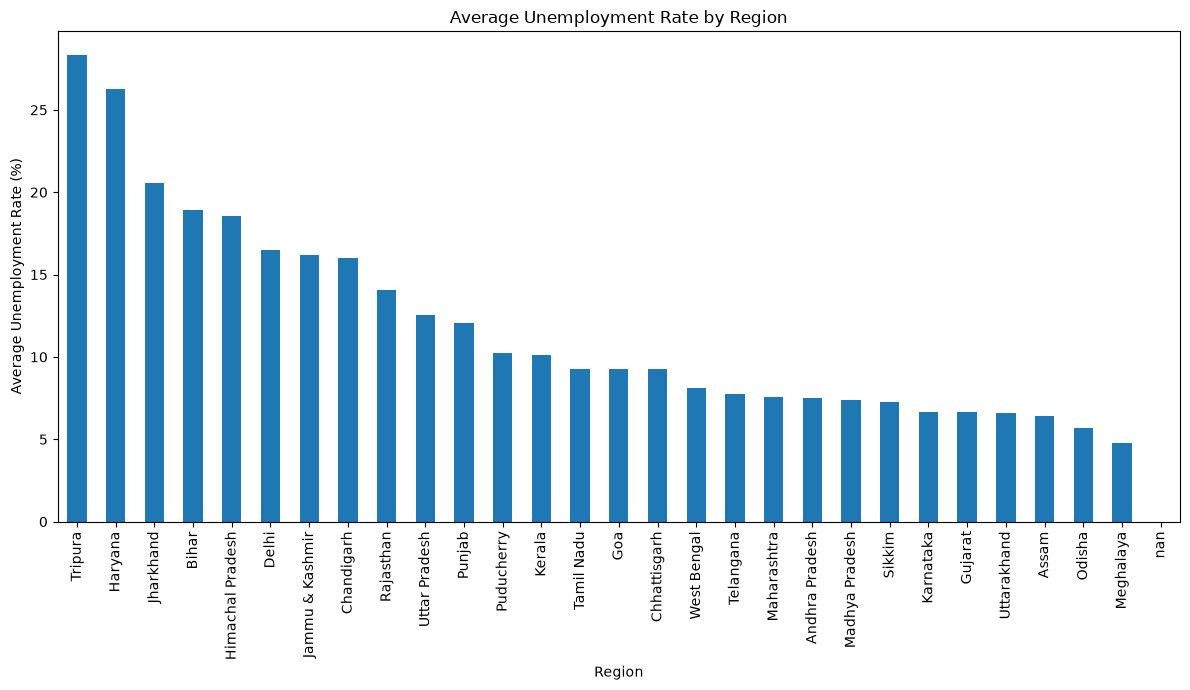


Monthly Unemployment Rate:
Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


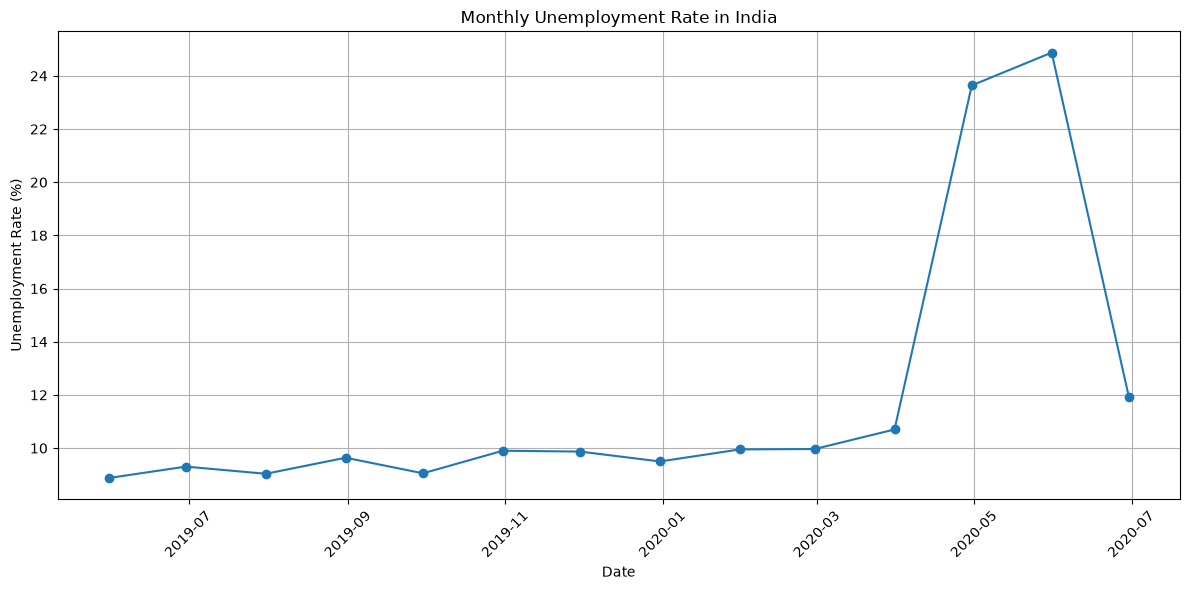


Top 10 Regions with Highest Average Unemployment:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


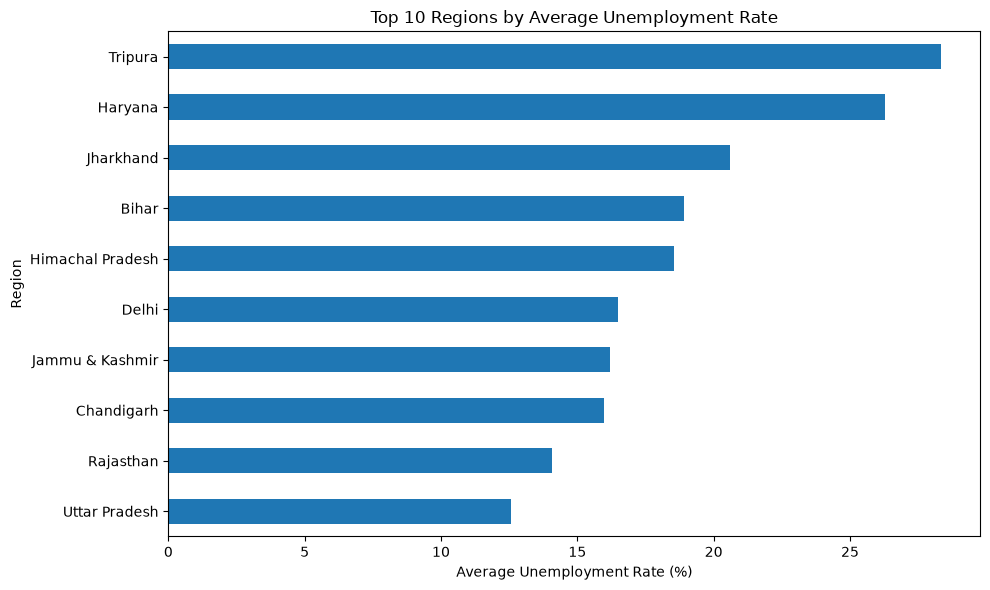


Top 10 Regions by Average Employment:
Region
Uttar Pradesh     2.809483e+07
Maharashtra       1.999020e+07
West Bengal       1.719854e+07
Bihar             1.236619e+07
Tamil Nadu        1.226955e+07
Gujarat           1.140201e+07
Madhya Pradesh    1.111548e+07
Karnataka         1.066712e+07
Rajasthan         1.004106e+07
Andhra Pradesh    8.154093e+06
Name: Estimated Employed, dtype: float64


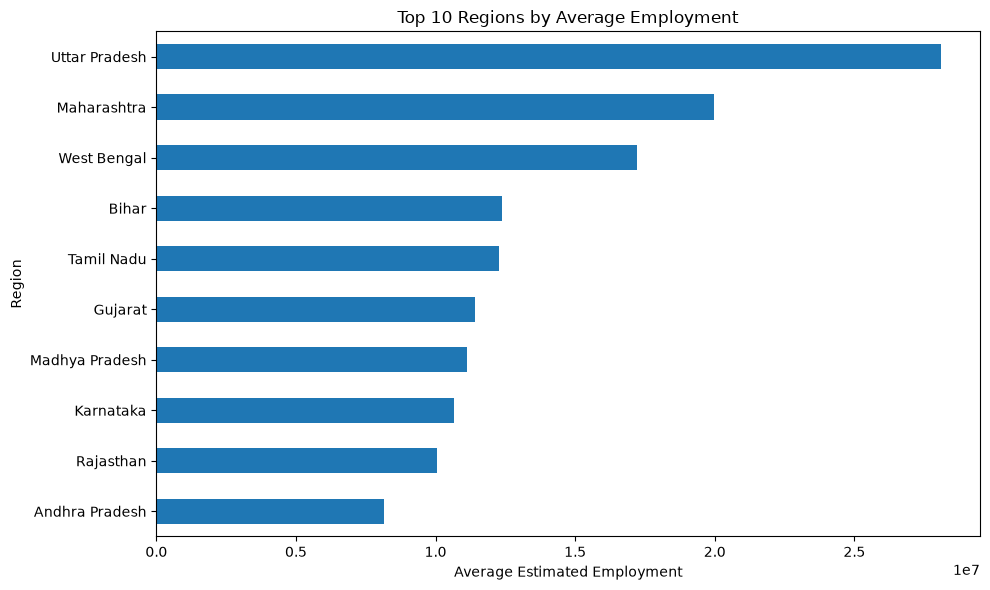


Average Labour Participation Rate:
42.63 %

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                     1.00   
Estimated Employed                                                 -0.22   
Estimated Labour Participation Rate (%)                             0.00   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                       -0.22   
Estimated Employed                                     1.00   
Estimated Labour Participation Rate (%)                0.01   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                             0.00  
Estimated Employed                                                          0.01  
Estimated Labour Participation Rate (%)                                     1.00  


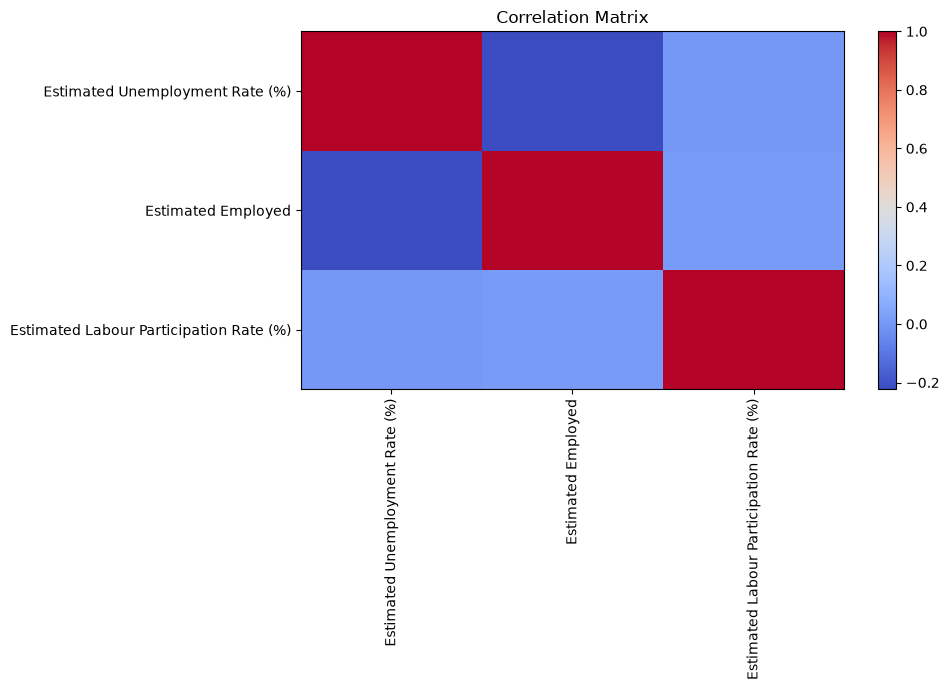


Average Unemployment Rate by Area:
Area
Urban    13.166614
Rural    10.324791
nan            NaN
Name: Estimated Unemployment Rate (%), dtype: float64


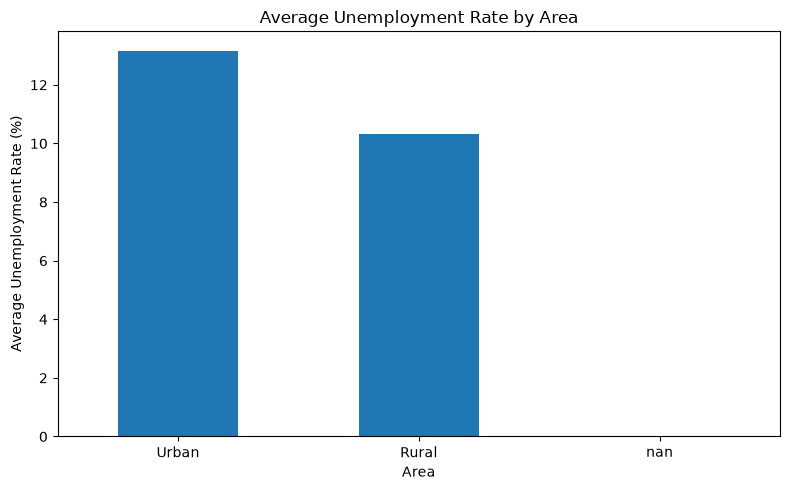


CONCLUSION

The unemployment dataset was analyzed using Python and Pandas.

Key analysis performed:
1. Dataset inspection and cleaning
2. Missing-value analysis
3. Statistical summary
4. Average unemployment rate calculation
5. Region-wise unemployment analysis
6. Monthly unemployment trend analysis
7. Identification of regions with high unemployment
8. Employment analysis
9. Labour participation analysis
10. Correlation analysis
11. Area-wise unemployment comparison

The visualizations help identify unemployment patterns,
regional differences, and changes over time.


Analysis Completed Successfully!


In [2]:
# ============================================================
# OIBSIP TASK 2 - UNEMPLOYMENT ANALYSIS WITH PYTHON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("Unemployment in India.csv")

print("=" * 60)
print("UNEMPLOYMENT ANALYSIS - OIBSIP TASK 2")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

# Remove unnecessary spaces from text columns
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].astype(str).str.strip()

# Convert Date column to datetime
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 3. BASIC INFORMATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 4. OVERALL UNEMPLOYMENT RATE
# ------------------------------------------------------------

rate_column = "Estimated Unemployment Rate (%)"

if rate_column in df.columns:

    average_unemployment = df[rate_column].mean()

    print("\nAverage Unemployment Rate:")
    print(round(average_unemployment, 2), "%")

    print("\nHighest Unemployment Rate:")
    highest = df.loc[df[rate_column].idxmax()]
    print(highest)

    print("\nLowest Unemployment Rate:")
    lowest = df.loc[df[rate_column].idxmin()]
    print(lowest)


# ------------------------------------------------------------
# 5. AVERAGE UNEMPLOYMENT RATE BY REGION
# ------------------------------------------------------------

if "Region" in df.columns and rate_column in df.columns:

    region_unemployment = (
        df.groupby("Region")[rate_column]
        .mean()
        .sort_values(ascending=False)
    )

    print("\nAverage Unemployment Rate by Region:")
    print(region_unemployment)

    # Bar chart
    plt.figure(figsize=(12, 7))
    region_unemployment.plot(kind="bar")
    plt.title("Average Unemployment Rate by Region")
    plt.xlabel("Region")
    plt.ylabel("Average Unemployment Rate (%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. MONTHLY UNEMPLOYMENT TREND
# ------------------------------------------------------------

if "Date" in df.columns and rate_column in df.columns:

    monthly_unemployment = (
        df.groupby("Date")[rate_column]
        .mean()
        .sort_index()
    )

    print("\nMonthly Unemployment Rate:")
    print(monthly_unemployment)

    plt.figure(figsize=(12, 6))
    plt.plot(
        monthly_unemployment.index,
        monthly_unemployment.values,
        marker="o"
    )
    plt.title("Monthly Unemployment Rate in India")
    plt.xlabel("Date")
    plt.ylabel("Unemployment Rate (%)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. HIGHEST 10 REGIONS BY UNEMPLOYMENT RATE
# ------------------------------------------------------------

if "Region" in df.columns and rate_column in df.columns:

    top_regions = (
        df.groupby("Region")[rate_column]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nTop 10 Regions with Highest Average Unemployment:")
    print(top_regions)

    plt.figure(figsize=(10, 6))
    top_regions.sort_values().plot(kind="barh")
    plt.title("Top 10 Regions by Average Unemployment Rate")
    plt.xlabel("Average Unemployment Rate (%)")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 8. EMPLOYMENT ANALYSIS
# ------------------------------------------------------------

employment_column = "Estimated Employed"

if employment_column in df.columns and "Region" in df.columns:

    region_employment = (
        df.groupby("Region")[employment_column]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nTop 10 Regions by Average Employment:")
    print(region_employment)

    plt.figure(figsize=(10, 6))
    region_employment.sort_values().plot(kind="barh")
    plt.title("Top 10 Regions by Average Employment")
    plt.xlabel("Average Estimated Employment")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. LABOUR PARTICIPATION RATE
# ------------------------------------------------------------

labour_column = "Estimated Labour Participation Rate (%)"

if labour_column in df.columns:

    average_labour_participation = df[labour_column].mean()

    print("\nAverage Labour Participation Rate:")
    print(round(average_labour_participation, 2), "%")


# ------------------------------------------------------------
# 10. CORRELATION ANALYSIS
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(include="number").columns

print("\nCorrelation Matrix:")
print(df[numeric_columns].corr().round(2))

plt.figure(figsize=(10, 7))
plt.imshow(df[numeric_columns].corr(), cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. AREA-WISE ANALYSIS
# ------------------------------------------------------------

if "Area" in df.columns and rate_column in df.columns:

    area_unemployment = (
        df.groupby("Area")[rate_column]
        .mean()
        .sort_values(ascending=False)
    )

    print("\nAverage Unemployment Rate by Area:")
    print(area_unemployment)

    plt.figure(figsize=(8, 5))
    area_unemployment.plot(kind="bar")
    plt.title("Average Unemployment Rate by Area")
    plt.xlabel("Area")
    plt.ylabel("Average Unemployment Rate (%)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 12. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
The unemployment dataset was analyzed using Python and Pandas.

Key analysis performed:
1. Dataset inspection and cleaning
2. Missing-value analysis
3. Statistical summary
4. Average unemployment rate calculation
5. Region-wise unemployment analysis
6. Monthly unemployment trend analysis
7. Identification of regions with high unemployment
8. Employment analysis
9. Labour participation analysis
10. Correlation analysis
11. Area-wise unemployment comparison

The visualizations help identify unemployment patterns,
regional differences, and changes over time.
""")

print("\nAnalysis Completed Successfully!")
